# Deepfake Detection & Attribution con Explainability

**Multimedia Forensics — Laurea Magistrale**  ·  pipeline multi-stream (RGB + Fourier) su Colab T4.

Pipeline:
1. **Feature**: immagine → ResNet18(ImageNet) → embedding ; spettro di Fourier → ResNet18 → embedding
2. **Classificatore a cascata** sugli embedding concatenati → *detection* (real/fake); se *fake* → *attribution* tra i generatori
3. **Explainability**: Grad-CAM sui due stream + **agent VLM open** (Qwen2.5-VL) che spiega il *perché*

> `Runtime → Change runtime type → T4 GPU` prima di eseguire.

## 0. Bootstrap (Colab)

Su un runtime Colab (VM remota) i file locali non esistono: questa cella clona il
repo **pubblico**, entra in `Progetto/`, installa le dipendenze e scarica il dataset.
In locale viene saltata automaticamente.

In [ ]:
# Esegui per primo. Idempotente: su Colab clona/AGGIORNA il repo, installa, scarica i dati.
# Forza sempre l'allineamento all'ultimo commit (scarta modifiche locali, es. output salvati).
import os

REPO = 'https://github.com/giuliopedicone02/MultimediaForensics.git'

def _on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _on_colab():
    BASE = '/content'
    REPO_DIR = os.path.join(BASE, 'MultimediaForensics')
    os.chdir(BASE)
    if not os.path.isdir(REPO_DIR):
        !git clone --depth 1 {REPO}
    else:
        # allinea all'ultimo commit, scartando ogni modifica locale (output del notebook)
        !git -C {REPO_DIR} fetch --depth 1 origin main -q && git -C {REPO_DIR} reset --hard origin/main -q
    os.chdir(os.path.join(REPO_DIR, 'Progetto'))
    print('cwd:', os.getcwd())
    !git -C {REPO_DIR} log -1 --oneline
    !pip -q install -r requirements.txt
    !pip -q install transformers accelerate bitsandbytes qwen-vl-utils sentencepiece
    # dataset (gitignorato): scarica solo se manca
    if (not os.path.isdir('data')) or (not any(os.scandir('data'))):
        !python scripts/download_data.py --per-class 300
    else:
        print('dataset gia presente: download saltato.')
else:
    print('Bootstrap saltato (locale).')

## 1. Setup

In [2]:
# Installazione dipendenze (su Colab torch/torchvision ci sono già).
# Decommenta alla prima esecuzione su Colab:
# !pip -q install transformers>=4.49 accelerate bitsandbytes qwen-vl-utils sentencepiece pyyaml

import torch
print('torch', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [3]:
# Rende importabile il package `dffa` in modo robusto.
# Cerca la cartella che contiene davvero `dffa/` (utile su Colab dopo un
# riavvio del runtime: la cwd torna a /content e va ritrovato il clone).
import sys, os

def _find_project_root():
    candidates = [
        os.getcwd(),                                   # qui
        os.path.abspath('..'),                         # se siamo in notebooks/
        'MultimediaForensics/Progetto',                # clone relativo
        '/content/MultimediaForensics/Progetto',       # clone tipico su Colab
    ]
    for c in candidates:
        if os.path.isdir(os.path.join(c, 'dffa')):
            return os.path.abspath(c)
    raise SystemExit(
        "Cartella 'Progetto' non trovata: esegui prima la cella 0 (Bootstrap)."
    )

ROOT = _find_project_root()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('project root:', ROOT)

import dffa
print('dffa', dffa.__version__)

project root: /content/MultimediaForensics/Progetto
dffa 0.1.0


## 2. Configurazione

In [4]:
from dffa.config import Config
from dffa.utils import set_seed, get_device, ensure_dir, save_json

cfg = Config(
    data_root=os.path.join(ROOT, 'data'),
    classes=['real', 'stylegan', 'stylegan3', 'sdxl'],
    max_per_class=250,      # ~1000 immagini totali; metti None per usarle tutte
    epochs=30,
    batch_size=32,
)
set_seed(cfg.seed)
device = get_device(cfg.device)
results_dir = ensure_dir(os.path.join(ROOT, cfg.results_dir))
print('device:', device, '| classi:', cfg.classes)

device: cuda | classi: ['real', 'stylegan', 'stylegan3', 'sdxl']


## 3. Dati

Disponi le immagini in `data/<classe>/` (es. `data/real`, `data/stylegan`, …).
Le classi assenti vengono ignorate: puoi partire anche con sole 2 classi.

In [5]:
from dffa.data import build_splits, list_samples
from collections import Counter

all_samples = list_samples(cfg)
if not all_samples:
    raise SystemExit('Nessuna immagine trovata: popola data/<classe>/ prima di proseguire.')
counts = Counter(cfg.classes[i] for _, i in all_samples)
print('immagini per classe:', dict(counts))

splits = build_splits(cfg)
print({k: len(v) for k, v in splits.items()})

immagini per classe: {'real': 250, 'stylegan': 250, 'stylegan3': 250, 'sdxl': 250}
{'train': 696, 'val': 152, 'test': 152}


## 4. Feature extraction (ResNet18 dual-stream, con cache)

In [6]:
from dffa.features import DualStreamExtractor
from dffa.engine import extract_embeddings

extractor = DualStreamExtractor(pretrained=True, freeze=True).to(device)

blobs = {}
for name in ['train', 'val', 'test']:
    cache = os.path.join(results_dir, f'emb_{name}.pt')
    blobs[name] = extract_embeddings(splits[name], cfg, extractor, device, cache_path=cache)
    print(name, blobs[name]['embeddings'].shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


embedding:   0%|          | 0/22 [00:00<?, ?it/s]

train torch.Size([696, 1024])


embedding:   0%|          | 0/5 [00:00<?, ?it/s]

val torch.Size([152, 1024])


embedding:   0%|          | 0/5 [00:00<?, ?it/s]

test torch.Size([152, 1024])


## 5. Sanity check — immagine vs spettro di Fourier

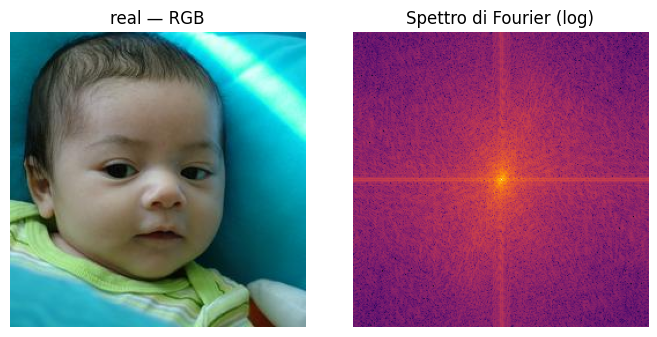

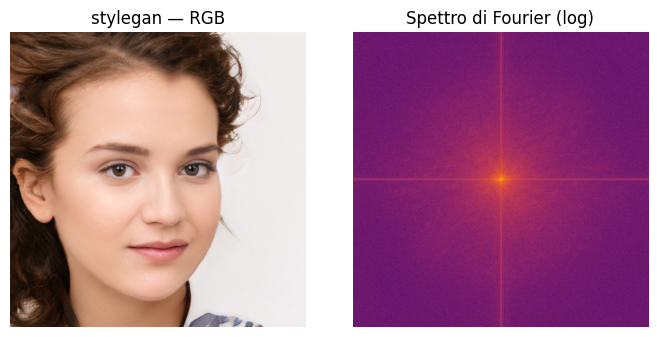

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
from dffa.features.fourier import fourier_spectrum

def show_pair(path, title):
    img = Image.open(path).convert('RGB')
    spec = fourier_spectrum(img, log=True)
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.4))
    ax[0].imshow(img); ax[0].set_title(f'{title} — RGB'); ax[0].axis('off')
    ax[1].imshow(spec, cmap='inferno'); ax[1].set_title('Spettro di Fourier (log)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()

# un esempio reale e uno fake (se disponibili)
by_cls = {}
for p, i in all_samples:
    by_cls.setdefault(cfg.classes[i], p)
for cls in ['real', 'stylegan']:
    if cls in by_cls:
        show_pair(by_cls[cls], cls)

## 6. Training del classificatore multi-task

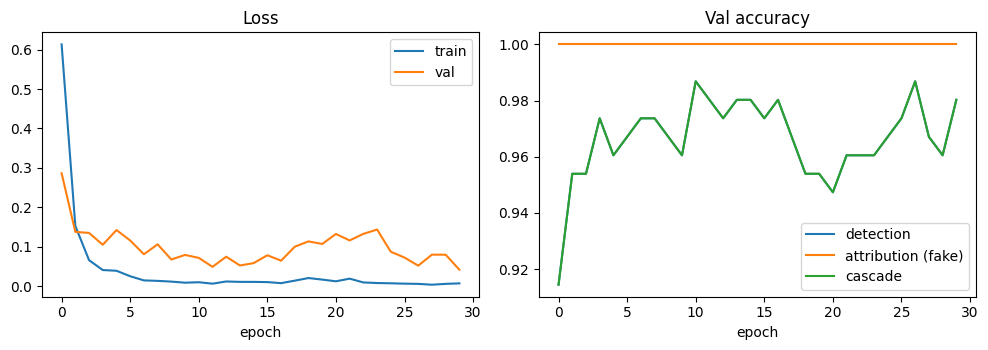

In [8]:
from dffa.engine import train_classifier

model, history = train_classifier(blobs['train'], blobs['val'], cfg, device)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['val_det_acc'], label='detection'); ax[1].plot(history['val_attr_acc'], label='attribution (fake)')
ax[1].plot(history['val_cascade_acc'], label='cascade')
ax[1].set_title('Val accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Valutazione sul test set

Detection acc          : 0.9868
Attribution acc (fake) : 1.0000
Cascade acc (end-to-end): 0.9868

== Detection (real vs fake, tutti i campioni) ==
              precision    recall  f1-score   support

        real       0.95      1.00      0.97        38
        fake       1.00      0.98      0.99       114

    accuracy                           0.99       152
   macro avg       0.97      0.99      0.98       152
weighted avg       0.99      0.99      0.99       152

== Attribution (SOLO fake, tra generatori) ==
              precision    recall  f1-score   support

    stylegan       1.00      1.00      1.00        38
   stylegan3       1.00      1.00      1.00        38
        sdxl       1.00      1.00      1.00        38

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



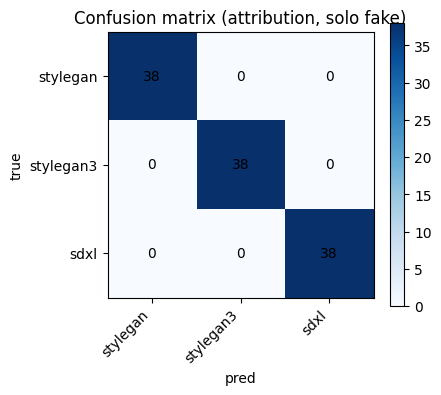

In [9]:
from dffa.engine import evaluate, _loader_from_blob
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_loader = _loader_from_blob(blobs['test'], cfg, shuffle=False)
res = evaluate(model, test_loader, cfg, device)
print(f"Detection acc          : {res['detection_acc']:.4f}")
print(f"Attribution acc (fake) : {res['attribution_acc']:.4f}")
print(f"Cascade acc (end-to-end): {res['cascade_acc']:.4f}")

print('\n== Detection (real vs fake, tutti i campioni) ==')
print(classification_report(res['detection_true'], res['detection_pred'],
                            target_names=['real', 'fake'], zero_division=0))
print('== Attribution (SOLO fake, tra generatori) ==')
gens = cfg.generator_classes
present = sorted(set(res['attribution_true']) | set(res['attribution_pred']))
print(classification_report(res['attribution_true'], res['attribution_pred'],
                            labels=present, target_names=[gens[i] for i in present],
                            zero_division=0))

cm = confusion_matrix(res['attribution_true'], res['attribution_pred'], labels=present)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(present))); ax.set_xticklabels([gens[i] for i in present], rotation=45, ha='right')
ax.set_yticks(range(len(present))); ax.set_yticklabels([gens[i] for i in present])
ax.set_xlabel('pred'); ax.set_ylabel('true'); ax.set_title('Confusion matrix (attribution, solo fake)')
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        ax.text(c, r, cm[r, c], ha='center', va='center')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 7-bis. Ablation — il confound della risoluzione

Le classi hanno **risoluzioni native diverse** (real/sdxl 256, StyleGAN 1024, StyleGAN3 244).
Portandole tutte a 224 con lo stesso resize, il *fattore* di ridimensionamento resta diverso
per classe e lascia una "firma" che il modello può sfruttare al posto dei veri artefatti
generativi, gonfiando le metriche. Qui lo dimostriamo e lo neutralizziamo:

1. **RAW vs CANONICA** — nessuna uniformazione (`canonical_size=None`) contro l'uniformazione
   a monte (tutte le immagini a `canonical_size`, stessa interpolazione, *prima* di RGB e Fourier).
   Se l'accuracy crolla passando da RAW a CANONICA, il confound era reale.
2. **Ablation degli stream** — RGB-only / Fourier-only / both sui dati canonici.

In [ ]:
from dataclasses import replace
from dffa.engine import slice_stream

# A) RAW (nessuna uniformazione) vs CANONICA (il run principale 'res' usa gia' canonical_size)
cfg_raw = replace(cfg, canonical_size=None)
sp_raw = build_splits(cfg_raw)
blobs_raw = {s: extract_embeddings(sp_raw[s], cfg_raw, extractor, device,
             cache_path=os.path.join(results_dir, f'emb_raw_{s}.pt'))
             for s in ['train', 'val', 'test']}
m_raw, _ = train_classifier(blobs_raw['train'], blobs_raw['val'], cfg_raw, device)
r_raw = evaluate(m_raw, _loader_from_blob(blobs_raw['test'], cfg_raw, shuffle=False), cfg_raw, device)

print('== Confound risoluzione: RAW vs CANONICA ==')
print(f"RAW  (canonical=None)   det={r_raw['detection_acc']:.3f}  attr(fake)={r_raw['attribution_acc']:.3f}  cascade={r_raw['cascade_acc']:.3f}")
print(f"CANONICA ({cfg.canonical_size})        det={res['detection_acc']:.3f}  attr(fake)={res['attribution_acc']:.3f}  cascade={res['cascade_acc']:.3f}")

# B) ablation degli stream sui dati canonici (blobs = run principale)
print('\n== Ablation stream (dati canonici) ==')
ablation = {}
for w in ['rgb', 'fourier', 'both']:
    bs = {s: slice_stream(blobs[s], w) for s in ['train', 'val', 'test']}
    mw, _ = train_classifier(bs['train'], bs['val'], cfg, device)
    rw = evaluate(mw, _loader_from_blob(bs['test'], cfg, shuffle=False), cfg, device)
    ablation[w] = {'detection_acc': rw['detection_acc'], 'attribution_acc': rw['attribution_acc'], 'cascade_acc': rw['cascade_acc']}
    print(f"  {w:8s} det={rw['detection_acc']:.3f}  attr(fake)={rw['attribution_acc']:.3f}  cascade={rw['cascade_acc']:.3f}")

## 7-ter. Generalizzazione — Leave-One-Generator-Out (LOGO)

La vera domanda forense: il rilevatore riconosce come *fake* un generatore **mai
visto** in addestramento? Per ogni generatore alleniamo la detection su
`real + (altri 2 generatori)` e testiamo su `real + il generatore escluso`.

Se l'accuracy (e soprattutto il *recall* sui fake mai visti) **crolla** rispetto al
~0.97 in-distribution, il modello non ha imparato la "fakeness" generale ma la firma
specifica di ciascun dataset/sorgente: prova diretta del confound di sorgente.

In [ ]:
from dffa.engine import cross_generator_detection

logo = cross_generator_detection(blobs, cfg, device)
print('== LOGO: detection su un generatore MAI visto in training ==')
print(f"(riferimento in-distribution: detection acc = {res['detection_acc']:.3f})\n")
for g, m in logo.items():
    print(f"  held-out {g:10s}: detection_acc={m['detection_acc']:.3f}  recall_fake_mai_visto={m['unseen_fake_recall']:.3f}")
import numpy as np
print(f"\n  media detection_acc held-out: {np.mean([m['detection_acc'] for m in logo.values()]):.3f}")

## 8. Grad-CAM — dove guarda la rete (RGB e Fourier)

detection: fake | attribution: stylegan


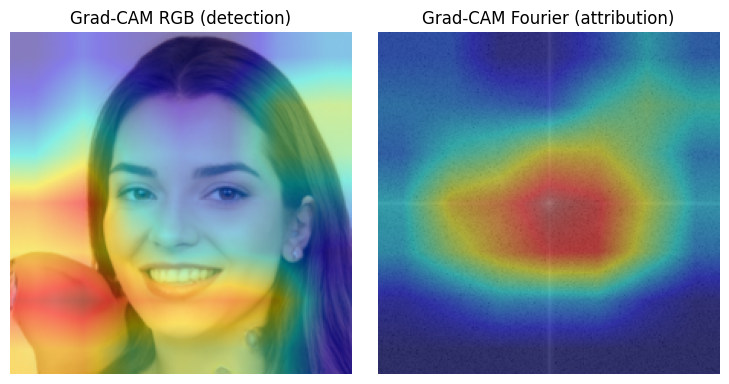

In [10]:
from dffa.data import ForensicsDataset
from dffa.explain import GradCAM, overlay_cam
from dffa.models import cascade_predict

# scelgo un campione FAKE dal test, così l'attribution è applicabile
sample_path, sample_attr = next((s for s in splits['test'] if cfg.classes[s[1]] != 'real'), splits['test'][0])
ds_one = ForensicsDataset([(sample_path, sample_attr)], cfg)
item = ds_one[0]
rgb = item['rgb'].unsqueeze(0).to(device)
fft = item['fourier'].unsqueeze(0).to(device)

# embedding + decisione a cascata (detection -> se fake -> attribution)
with torch.no_grad():
    emb = extractor(rgb, fft)
    pred, decisions = cascade_predict(model, emb, cfg.generator_classes)
dec = decisions[0]
det_cls = int(pred['detection_pred'][0]); gen_cls = int(pred['attribution_pred'][0])
print('detection:', dec['detection'], '| attribution:', dec['attribution'])

# Grad-CAM sullo stream RGB rispetto al logit di detection predetto
cam_rgb = GradCAM(extractor.rgb, extractor.rgb.target_layer)
heat_rgb = cam_rgb(rgb, score_fn=lambda f: model(torch.cat([f, extractor.fourier(fft)],1)).detection_logits[:, det_cls])
cam_rgb.remove()

# Grad-CAM sullo stream Fourier rispetto al generatore predetto (attribution)
cam_fft = GradCAM(extractor.fourier, extractor.fourier.target_layer)
heat_fft = cam_fft(fft, score_fn=lambda f: model(torch.cat([extractor.rgb(rgb), f],1)).attribution_logits[:, gen_cls])
cam_fft.remove()

ov_rgb = overlay_cam(item['rgb'], heat_rgb)
ov_fft = overlay_cam(item['fourier'], heat_fft)
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.8))
ax[0].imshow(ov_rgb); ax[0].set_title('Grad-CAM RGB (detection)'); ax[0].axis('off')
ax[1].imshow(ov_fft); ax[1].set_title('Grad-CAM Fourier (attribution)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 9. Agent VLM — spiegazione in linguaggio naturale

L'agent open (Qwen2.5-VL, 4-bit su T4) osserva RGB + Fourier + Grad-CAM e le
probabilità del classificatore, e spiega *perché* real/fake e *perché* quel
generatore. Senza GPU/modello ricade su una spiegazione template-based.

In [11]:
from dffa.explain import VLMExplainer, build_evidence
from dffa.explain.gradcam import _jet
from PIL import Image as PILImage

explainer = VLMExplainer(cfg.vlm_model_id, load_in_4bit=cfg.vlm_load_in_4bit,
                         max_new_tokens=cfg.vlm_max_new_tokens, device=str(device))
loaded = explainer.load() if cfg.vlm_enabled else False
print('VLM caricato:', loaded)

# evidenze numeriche per il campione di Grad-CAM
evidence = build_evidence(
    detection_prob=pred['detection_prob'][0].cpu().numpy(),
    attribution_prob=pred['attribution_prob'][0].cpu().numpy(),
    generator_classes=cfg.generator_classes,
    cam_stats={'mean': float(heat_rgb.mean()), 'max': float(heat_rgb.max())},
)

images = {
    'rgb': PILImage.open(sample_path).convert('RGB'),
    'fourier': PILImage.fromarray((_jet(fourier_spectrum(PILImage.open(sample_path).convert('RGB')))*255).astype('uint8')),
    'gradcam': PILImage.fromarray(ov_rgb),
}
exp = explainer.explain(images, evidence)
print(f'[fonte: {exp.source}]\n')
print(exp.text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM caricato: True


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[fonte: vlm]

L'immagine originale mostra una persona con capelli lunghi e una sorriso amichevole, ma l'analisi del spettro di Fourier evidenzia una serie di artefatti GAN, come griglie periodiche e picchi di frequenza. Queste caratteristiche sono tipiche delle immagini generatesse tramite tecniche GAN, come StyleGAN o StyleGAN3. 

La mappa Grad-CAM ha evidenziato le regioni del volto e delle orecchie, dove il classificatore ha trovato segni di artefatti GAN. Questo suggerisce che l'immagine sia stata generata da un modello GAN, probabilmente StyleGAN o StyleGAN3, dato che queste tecniche producono simili artefatti.

Le predizioni del classificatore indicano che l'immagine è "fake" con una certificazione di 99.97% e una probabilità reale di 0.0003. Questo alto grado di certificazione conferma la classificazione come falsa. 

L'attribuzione del generatore è attribuita a StyleGAN con una certificazione di 99.99%, con una distribuzione di 0.0001 per StyleGAN3 e 0.0001 per Sdxl. Questo ris

## 10. Salvataggio dei risultati

In [ ]:
summary = {
    'config': cfg.__dict__,
    'counts': dict(counts),
    'splits': {k: len(v) for k, v in splits.items()},
    'detection_acc': res['detection_acc'],
    'attribution_acc': res['attribution_acc'],
    'cascade_acc': res['cascade_acc'],
    # ablation (vedi sezione 7-bis): confound della risoluzione + contributo degli stream
    'ablation_raw': {'detection_acc': r_raw['detection_acc'],
                     'attribution_acc': r_raw['attribution_acc'],
                     'cascade_acc': r_raw['cascade_acc']},
    'ablation_streams': ablation,
    'logo_cross_generator': logo,
    'example_explanation': {'path': sample_path, 'detection': dec['detection'],
                            'attribution': dec['attribution'], 'source': exp.source, 'text': exp.text},
}
save_json(summary, os.path.join(results_dir, 'summary.json'))
torch.save(model.state_dict(), os.path.join(results_dir, 'classifier.pt'))
print('Salvato in', results_dir)